# 01 — EDA & Model Comparison

**Goal of this notebook:** understand the data, then compare three baselines
(Logistic Regression, Naive Bayes, Linear SVM) honestly before committing to one.

> Reminder: this classifies the *tone* of text, not a person's condition. The
> urgent-distress signal lives in a separate rule layer (`src/distress.py`) and is
> deliberately **not** evaluated as a model class here.

**Workflow:** load → inspect class balance → look at text length → preprocess →
compare models with cross-validated macro-F1 → inspect the confusion matrix of the
winner → read the most informative words per class.

In [10]:
# Make the project root importable when running from notebooks/
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import TONE_LABELS, RANDOM_STATE
from src.preprocessing import preprocess

pd.set_option("display.max_colwidth", 80)
print("Tones:", TONE_LABELS)

Tones: ['neutral', 'stress', 'anxiety', 'sadness', 'anger', 'loneliness']


## 1. Load the data

We load `data/processed/train.csv` (columns: `text`, `label`). The repo ships a tiny
sample so this runs immediately — swap in remapped GoEmotions / dair-ai data for real
results.

In [11]:
df = pd.read_csv(ROOT / "data" / "processed" / "train.csv")
print(f"Rows: {len(df)}")
df.head()

Rows: 9432


,text,label
0,i must bring some perspective into the equation consider how you would feel ...,sadness
1,i always feel humiliated,sadness
2,i feel nervous when anyone gets too close,anxiety
3,ive definitely been feeling low this past week because ive been sick ever si...,sadness
4,i see those forms that i havent do yet i just feel very agitated,anger


## 2. Class balance

**Why this matters first:** emotion datasets are almost always imbalanced (lots of
`neutral`, little `loneliness`). If we ignore this, the model can score high accuracy
by just predicting the majority class. This chart tells us whether we need
`class_weight="balanced"` (we do) and which classes will be hardest.

label
neutral       2500
stress         233
anxiety       1811
sadness       2500
anger         2159
loneliness     229
Name: count, dtype: int64


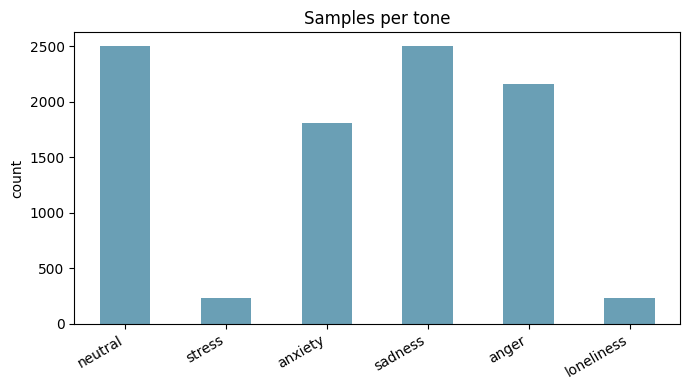

In [12]:
counts = df["label"].value_counts().reindex(TONE_LABELS).fillna(0).astype(int)
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax, color="#6a9fb5")
ax.set_title("Samples per tone")
ax.set_ylabel("count")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Text length by tone

A quick sanity check: are some tones systematically longer/shorter? Big differences
can become an accidental shortcut the model latches onto instead of meaning.

                 mean  min   max
label                           
anger       19.229736  2.0  62.0
anxiety     18.637769  2.0  60.0
loneliness  19.519651  4.0  64.0
neutral     19.848800  2.0  64.0
sadness     18.104800  3.0  66.0
stress      22.038627  3.0  59.0


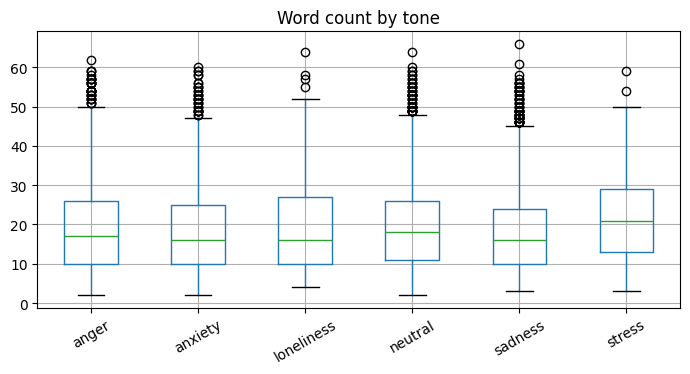

In [13]:
df["word_count"] = df["text"].str.split().str.len()
print(df.groupby("label")["word_count"].describe()[["mean", "min", "max"]])

fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="word_count", by="label", ax=ax, rot=30)
ax.set_title("Word count by tone")
plt.suptitle("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 4. See what preprocessing does

Before trusting the pipeline, look at a few before/after examples. Confirm that
negations (`not`, `no`, `never`) survive — that is the single most important
preprocessing decision for emotional text.

In [14]:
for raw in df["text"].head(4):
    print(f"RAW : {raw}")
    print(f"CLEAN: {preprocess(raw)}\n")

df["clean"] = df["text"].astype(str).apply(preprocess)

RAW : i must bring some perspective into the equation consider how you would feel if you went a week without calling and then phoned up to find out youd missed your final opportunity to talk with a parent
CLEAN: must bring perspective equation consider would feel went week without calling phoned find youd missed final opportunity talk parent

RAW : i always feel humiliated
CLEAN: always feel humiliated

RAW : i feel nervous when anyone gets too close
CLEAN: feel nervous anyone get close

RAW : ive definitely been feeling low this past week because ive been sick ever since bfd but im determined to get my health back
CLEAN: ive definitely feeling low past week ive sick ever since bfd im determined get health back



## 5. Compare three baselines

We reuse the *exact* pipeline from `src/train.py` so the notebook and the training
script never drift apart. We score with **cross-validated macro-F1** — macro weights
every tone equally, which is what we care about with imbalanced classes.

> Note: `LinearSVC` has no `predict_proba`, so it can't power the confidence-score
> feature in the app. We still compare it here for accuracy, but `logreg` stays the
> default for the product.

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from src.train import build_pipeline

# Small sample data -> use fewer folds so each fold still has every class.
min_class = df["label"].value_counts().min()
n_splits = max(2, min(5, int(min_class)))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"Using {n_splits}-fold CV (smallest class has {min_class} samples)\n")

results = {}
for name in ["logreg", "nb", "svm"]:
    scores = cross_val_score(
        build_pipeline(name), df["clean"], df["label"],
        cv=cv, scoring="f1_macro",
    )
    results[name] = scores
    print(f"{name:7s} macro-F1: {scores.mean():.3f}  (+/- {scores.std():.3f})")

best = max(results, key=lambda k: results[k].mean())
print(f"\nBest by mean macro-F1: {best!r}")

Using 5-fold CV (smallest class has 229 samples)

logreg  macro-F1: 0.879  (+/- 0.011)
nb      macro-F1: 0.588  (+/- 0.012)
svm     macro-F1: 0.902  (+/- 0.015)

Best by mean macro-F1: 'svm'


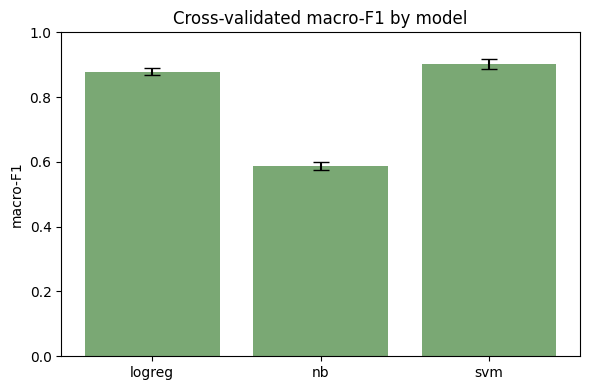

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
means = [results[m].mean() for m in results]
errs = [results[m].std() for m in results]
ax.bar(list(results.keys()), means, yerr=errs, capsize=6, color="#7aa874")
ax.set_title("Cross-validated macro-F1 by model")
ax.set_ylabel("macro-F1")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. Confusion matrix of the best model

Cross-validated **predictions** (`cross_val_predict`) give every sample one
out-of-fold prediction, so the matrix reflects generalization rather than memorized
training data. Expect blur between **anger↔stress** and **sadness↔loneliness** — those
tones genuinely overlap in language. Narrate that in your report; it shows judgment.

              precision    recall  f1-score   support

       anger       0.91      0.92      0.92      2159
     anxiety       0.90      0.91      0.91      1811
  loneliness       0.85      0.91      0.88       229
     neutral       0.93      0.94      0.93      2500
     sadness       0.93      0.92      0.93      2500
      stress       0.91      0.80      0.85       233

    accuracy                           0.92      9432
   macro avg       0.91      0.90      0.90      9432
weighted avg       0.92      0.92      0.92      9432



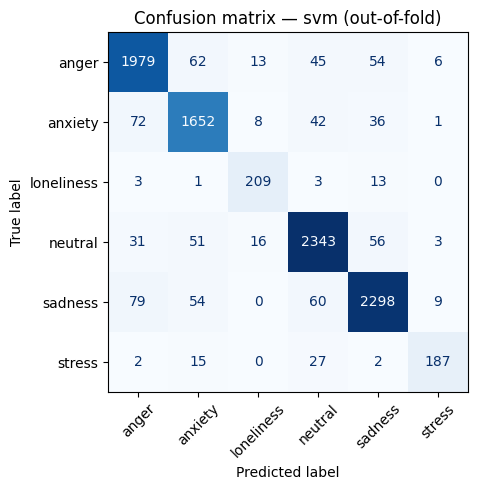

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

labels_present = sorted(df["label"].unique())
y_pred = cross_val_predict(build_pipeline(best), df["clean"], df["label"], cv=cv)

print(classification_report(df["label"], y_pred, zero_division=0))

cm = confusion_matrix(df["label"], y_pred, labels=labels_present)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels_present).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False
)
ax.set_title(f"Confusion matrix — {best} (out-of-fold)")
plt.tight_layout()
plt.show()

## 7. Most informative words per tone

Interpretability is a portfolio differentiator. We fit the winning pipeline on all
the data and read the top TF-IDF features pushing toward each class. This is a great
place to catch the model learning a dataset artifact instead of real emotion.

*(Works for `logreg`/`nb`, which expose per-class coefficients. SVM's `coef_` is
also readable; we guard for the attribute.)*

In [18]:
pipe = build_pipeline(best).fit(df["clean"], df["label"])
vec = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())

if hasattr(clf, "coef_"):
    classes = clf.classes_
    coefs = clf.coef_
    # Binary models store one row; expand to the positive class view.
    if coefs.shape[0] == 1:
        coefs = np.vstack([-coefs[0], coefs[0]])
    TOP = 8
    for cls, row in zip(classes, coefs):
        top = feature_names[np.argsort(row)[-TOP:][::-1]]
        print(f"{cls:11s}: {', '.join(top)}")
else:
    print("This classifier does not expose coefficients.")

anger      : dangerous, distracted, fucked, offended, irritable, bothered, violent, greedy
anxiety    : shaken, terrified, reluctant, vulnerable, unsure, apprehensive, uncertain, intimidated
loneliness : alone, isolated, lonely, no one, feel isolated, feel alone, nobody, feel lonely
neutral    : amazed, sweet, sincere, resolved, supporting, beloved, friendly, mellow
sadness    : melancholy, unfortunate, lethargic, troubled, rejected, needy, punished, dull
stress     : overwhelmed, pressured, pressure, much, feel pressured, feeling overwhelmed, way much, feel overwhelmed


## 8. Takeaways → write these into `reports/metrics.md`

- Best model + its CV macro-F1 (with the std).
- Which tones the confusion matrix shows blurring, and a plausible reason.
- Whether the top-words look like *real emotion* or *dataset artifacts*.
- The weakest class (usually the smallest one) — flag it as a data-collection need.

**Next:** replace the sample CSV with real remapped data and re-run top to bottom.
The numbers above are from the real dair-ai/emotion data (~9.4k rows): logreg ~0.88 macro-F1.